In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Train.csv')
df_test = pd.read_csv('Test.csv')

In [3]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18594 entries, 0 to 18593
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           18594 non-null  object 
 1   customer_id                  18594 non-null  int64  
 2   country_id                   18594 non-null  object 
 3   tbl_loan_id                  18594 non-null  int64  
 4   lender_id                    18594 non-null  int64  
 5   loan_type                    18594 non-null  object 
 6   Total_Amount                 18594 non-null  float64
 7   Total_Amount_to_Repay        18594 non-null  float64
 8   disbursement_date            18594 non-null  object 
 9   due_date                     18594 non-null  object 
 10  duration                     18594 non-null  int64  
 11  New_versus_Repeat            18594 non-null  object 
 12  Amount_Funded_By_Lender      18594 non-null  float64
 13  Lender_portion_F

In [4]:
df_test.head()

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid
0,ID_269404226088267278,269404,Kenya,226088,267278,Type_1,1919.0,1989.0,2022-07-27,2022-08-03,7,Repeat Loan,575.7,0.300000,597.0
1,ID_255356300042267278,255356,Kenya,300042,267278,Type_1,2138.0,2153.0,2022-11-16,2022-11-23,7,Repeat Loan,0.0,0.000000,0.0
2,ID_257026243764267278,257026,Kenya,243764,267278,Type_1,8254.0,8304.0,2022-08-24,2022-08-31,7,Repeat Loan,207.0,0.025079,208.0
3,ID_264617299409267278,264617,Kenya,299409,267278,Type_1,3379.0,3379.0,2022-11-15,2022-11-22,7,Repeat Loan,1013.7,0.300000,1014.0
4,ID_247613296713267278,247613,Kenya,296713,267278,Type_1,120.0,120.0,2022-11-10,2022-11-17,7,Repeat Loan,36.0,0.300000,36.0


In [5]:
df_test.rename(columns={'ID':'id', 'Total_Amount':'total_amount', 'Total_Amount_to_Repay':'total_amount_to_repay', 'New_versus_Repeat':'new_versus_repeat',  
                   'Amount_Funded_By_Lender':'amount_funded_by_lender', 'Lender_portion_Funded':'lender_portion_funded',
                   'Lender_portion_to_be_repaid':'lender_portion_to_be_repaid'}, inplace=True)

In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18594 entries, 0 to 18593
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           18594 non-null  object 
 1   customer_id                  18594 non-null  int64  
 2   country_id                   18594 non-null  object 
 3   tbl_loan_id                  18594 non-null  int64  
 4   lender_id                    18594 non-null  int64  
 5   loan_type                    18594 non-null  object 
 6   total_amount                 18594 non-null  float64
 7   total_amount_to_repay        18594 non-null  float64
 8   disbursement_date            18594 non-null  object 
 9   due_date                     18594 non-null  object 
 10  duration                     18594 non-null  int64  
 11  new_versus_repeat            18594 non-null  object 
 12  amount_funded_by_lender      18594 non-null  float64
 13  lender_portion_f

### Preprocessing

In [7]:
df_test.groupby('country_id')['id'].count().sort_values(ascending=False)

country_id
Kenya    15069
Ghana     3525
Name: id, dtype: int64

#### Loan Types

In [8]:
loan_type_count = df_test.groupby('loan_type')['id'].count().sort_values(ascending=False).reset_index(name='count')
print(loan_type_count)

   loan_type  count
0     Type_1  13618
1     Type_3   3039
2     Type_7    592
3     Type_2    454
4     Type_5    298
5     Type_4    253
6     Type_6     98
7    Type_10     96
8     Type_9     42
9     Type_8     37
10   Type_14     17
11   Type_11     14
12   Type_18     12
13   Type_23      6
14   Type_12      5
15   Type_24      4
16   Type_17      3
17   Type_13      2
18   Type_20      1
19   Type_22      1
20   Type_15      1
21   Type_21      1


#### Loan Duration

In [9]:
df_test['duration'].describe()

count    18594.000000
mean        13.530763
std         36.437325
min          1.000000
25%          7.000000
50%          7.000000
75%          7.000000
max        849.000000
Name: duration, dtype: float64

In [10]:
print((df_test.groupby('duration').size().sort_values(ascending=False)).head(60))

duration
7      17365
14       311
180      290
30       211
90        56
365       51
240       39
300       37
60        33
210       26
150       19
29        14
45        14
31        10
360        9
27         9
4          8
25         7
92         7
120        6
44         6
1          5
270        5
42         4
21         4
3          4
91         4
265        3
59         3
22         3
61         3
62         3
182        2
5          2
6          2
26         2
15         2
20         2
183        2
330        1
8          1
87         1
23         1
24         1
153        1
152        1
122        1
28         1
43         1
849        1
dtype: int64


#### Loan Interest Rates

In [11]:
#calculationg the interest rate
df_test['interest_rate'] = ((df_test['total_amount_to_repay'] - df_test['total_amount']) / 
                         (df_test['total_amount'] * (df_test['duration'] / 365))) * 100
df_test = df_test[['id', 'customer_id', 'country_id', 'tbl_loan_id', 'lender_id',	'loan_type', 'total_amount', 'total_amount_to_repay', 'interest_rate', 'disbursement_date', 'due_date', 'duration', 'amount_funded_by_lender', 'lender_portion_funded', 'lender_portion_to_be_repaid', 'new_versus_repeat']]
df_test.head()

,id,customer_id,country_id,tbl_loan_id,lender_id,loan_type,total_amount,total_amount_to_repay,interest_rate,disbursement_date,due_date,duration,amount_funded_by_lender,lender_portion_funded,lender_portion_to_be_repaid,new_versus_repeat
0,ID_269404226088267278,269404,Kenya,226088,267278,Type_1,1919.0,1989.0,190.203231,2022-07-27,2022-08-03,7,575.7,0.300000,597.0,Repeat Loan
1,ID_255356300042267278,255356,Kenya,300042,267278,Type_1,2138.0,2153.0,36.582921,2022-11-16,2022-11-23,7,0.0,0.000000,0.0,Repeat Loan
2,ID_257026243764267278,257026,Kenya,243764,267278,Type_1,8254.0,8304.0,31.586417,2022-08-24,2022-08-31,7,207.0,0.025079,208.0,Repeat Loan
3,ID_264617299409267278,264617,Kenya,299409,267278,Type_1,3379.0,3379.0,0.000000,2022-11-15,2022-11-22,7,1013.7,0.300000,1014.0,Repeat Loan
4,ID_247613296713267278,247613,Kenya,296713,267278,Type_1,120.0,120.0,0.000000,2022-11-10,2022-11-17,7,36.0,0.300000,36.0,Repeat Loan


In [12]:
df_test['interest_rate'].describe()

count    18594.000000
mean       107.946904
std        248.345987
min      -5212.882049
25%          0.000000
50%         74.280111
75%        156.429848
max       5214.285714
Name: interest_rate, dtype: float64

In [13]:
print(f"There are {len(df_test[df_test['interest_rate'] == 0])} loan transactions with a 0% interest rate")

There are 5220 loan transactions with a 0% interest rate


#### Daily Loan Cost

In [14]:
df_test = df_test.copy()
df_test['daily_loan_cost'] = ((df_test['total_amount_to_repay'] - df_test['total_amount']) / df_test['duration'])
df_test['daily_loan_cost']

0        10.000000
1         2.142857
2         7.142857
3         0.000000
4         0.000000
           ...    
18589     7.415714
18590     0.000000
18591     5.870000
18592    24.714286
18593     0.000000
Name: daily_loan_cost, Length: 18594, dtype: float64

In [15]:
print(df_test['daily_loan_cost'].describe())

count    18594.000000
mean        28.565237
std        107.111369
min       -631.340000
25%          0.000000
50%          6.917143
75%         23.566786
max       5232.142857
Name: daily_loan_cost, dtype: float64


#### New Vs Repeat

<Axes: xlabel='new_versus_repeat', ylabel='count'>

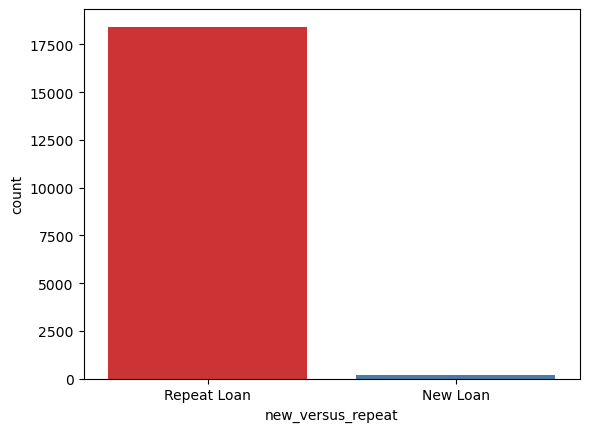

In [16]:
sns.countplot(x='new_versus_repeat', data=df_test, hue= 'new_versus_repeat', palette='Set1')

#### Dates

In [17]:
df_test['due_date'] = pd.to_datetime(df_test['due_date'])

In [18]:
df_test['due_month'] = df_test['due_date'].dt.month

In [19]:
df_test['due_date'] = df_test['due_date'].dt.strftime('%Y-%m-%d')

#### Testing for multicollinearity

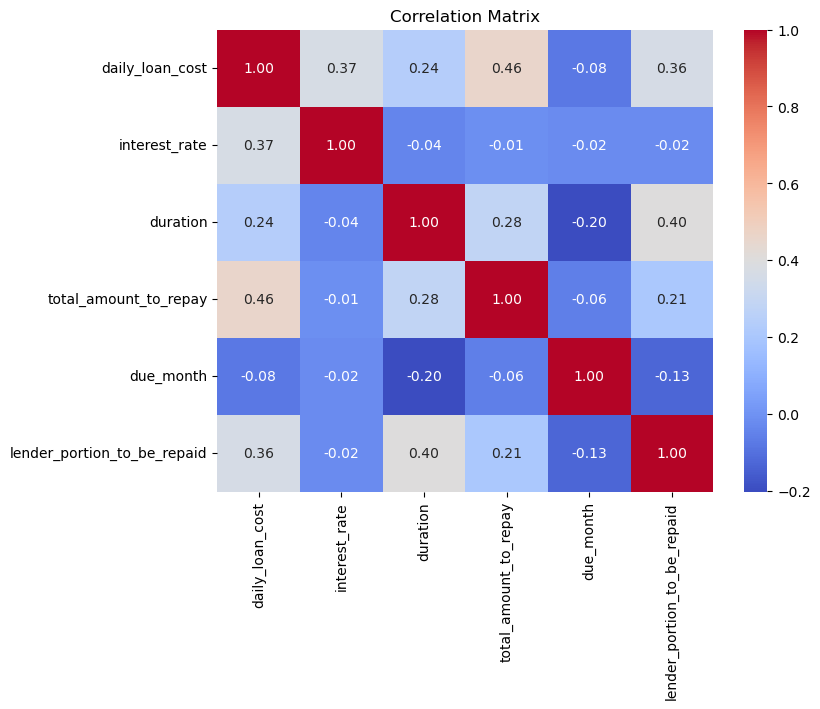

In [20]:
# numerical columns to check the correlation
numerical_columns = ['daily_loan_cost', 'interest_rate', 'duration', 'total_amount_to_repay', 'due_month', 'lender_portion_to_be_repaid']
correlation_matrix = df_test[numerical_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.savefig('corr_matrix1.png', dpi=400, bbox_inches='tight' )
plt.show()

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Include relevant features
features = ['daily_loan_cost', 'interest_rate', 'duration', 'total_amount_to_repay', 'due_month', 'lender_portion_to_be_repaid']

# Add a constant for VIF calculation
X = add_constant(df_test[features])

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                       Feature        VIF
0                        const  18.048841
1              daily_loan_cost   1.758839
2                interest_rate   1.259458
3                     duration   1.293110
4        total_amount_to_repay   1.377474
5                    due_month   1.046748
6  lender_portion_to_be_repaid   1.343500


### Model Building

In [22]:
df_test.columns

Index(['id', 'customer_id', 'country_id', 'tbl_loan_id', 'lender_id',
       'loan_type', 'total_amount', 'total_amount_to_repay', 'interest_rate',
       'disbursement_date', 'due_date', 'duration', 'amount_funded_by_lender',
       'lender_portion_funded', 'lender_portion_to_be_repaid',
       'new_versus_repeat', 'daily_loan_cost', 'due_month'],
      dtype='object')

In [23]:
#feature selection
df1_test = df_test[['id', 'loan_type', 'total_amount_to_repay', 'interest_rate', 'duration', 'daily_loan_cost', 'new_versus_repeat', 
                    'due_month', 'lender_portion_to_be_repaid']]
df1_test.head()

,id,loan_type,total_amount_to_repay,interest_rate,duration,daily_loan_cost,new_versus_repeat,due_month,lender_portion_to_be_repaid
0,ID_269404226088267278,Type_1,1989.0,190.203231,7,10.000000,Repeat Loan,8,597.0
1,ID_255356300042267278,Type_1,2153.0,36.582921,7,2.142857,Repeat Loan,11,0.0
2,ID_257026243764267278,Type_1,8304.0,31.586417,7,7.142857,Repeat Loan,8,208.0
3,ID_264617299409267278,Type_1,3379.0,0.000000,7,0.000000,Repeat Loan,11,1014.0
4,ID_247613296713267278,Type_1,120.0,0.000000,7,0.000000,Repeat Loan,11,36.0


In [24]:
df1_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18594 entries, 0 to 18593
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           18594 non-null  object 
 1   loan_type                    18594 non-null  object 
 2   total_amount_to_repay        18594 non-null  float64
 3   interest_rate                18594 non-null  float64
 4   duration                     18594 non-null  int64  
 5   daily_loan_cost              18594 non-null  float64
 6   new_versus_repeat            18594 non-null  object 
 7   due_month                    18594 non-null  int32  
 8   lender_portion_to_be_repaid  18594 non-null  float64
dtypes: float64(4), int32(1), int64(1), object(3)
memory usage: 1.2+ MB


In [25]:
df1_test.to_csv('df1_test.csv')

#### Model Testing

In [26]:
#selecting features for prediction
X_df1_test = df1_test[['loan_type', 'total_amount_to_repay', 'interest_rate', 'duration', 'daily_loan_cost', 'new_versus_repeat', 
                       'due_month', 'lender_portion_to_be_repaid']]